### 1. Configuração do Ambiente

In [ ]:
#!pip install "cognite-sdk[pandas]" matplotlib seaborn tensorflow plotly -q

import os
from datetime import datetime
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from IPython.display import display
from sklearn.preprocessing import RobustScaler
from statsmodels.tsa.stattools import acf
from industrial_ts.dataloader import DataLoader
import json
from getpass import getpass
#import tensorflow as tf
#from tensorflow import keras

print("Bibliotecas importadas com sucesso!")






Updated: UnsupervisedStateSegmenter now supports multi-channel (multivariate) series.

Bibliotecas importadas com sucesso!


/home/ferna/fe/lib/python3.12/site-packages/ipykernel/ipkernel.py:772: UserWarning: You are using version='7.83.1' of the SDK, however version='7.91.2' is available. To suppress this warning, either upgrade or do the following:
>>> from cognite.client.config import global_config
>>> global_config.disable_pypi_version_check = True
  _threading_Thread_run(self)


In [7]:
import debugpy
debugpy.listen(('0.0.0.0', 5678))






('0.0.0.0', 5678)

In [8]:
os.environ['COGNITE_CLIENT_SECRET'] = getpass("Enter COGNITE_CLIENT")






### 2. Ativar o DataLoader

In [9]:
import importlib
import sys
importlib.reload(sys.modules['industrial_ts.dataloader'])
from industrial_ts.dataloader import DataLoader
dl = DataLoader()
dl.add_segments(segments=3, window=10, step=10, series=[
    'PH (CBM) 1st Stg ActCompr Poly Head',
    'PH (CBM) 1st Stage ActShaft Power',
    'PH (CBM) 1st Stg ActCompr Poly Head',
    'PH (CBM) 1st Stage ActPress Ratio'  
], path="segmenter_model_10.pkl"
)
#dl.segmenter.save("segmenter_model_10.pkl")








Buscando dados para as 12 séries temporais encontradas.


### 10 Pós-processamento

In [10]:
for i in [2]:
    dl.df['states'].replace(i, 1, inplace=True) # Merge states 1 and 2







/tmp/ipykernel_117826/4230046523.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dl.df['states'].replace(i, 1, inplace=True) # Merge states 1 and 2


In [11]:
dl.add_time_to_change_state_timestamp()






# seqKAN (artigo) - treino

Notebook baseado em `seqKAN_old.ipynb`, ajustado para usar `TS_seqKAN` (artigo).


In [12]:
from industrial_ts.seqKAN import TSDF_seqKAN







In [13]:
aux_gate_params = {
    'alpha_x': 1,
}

kan_params = {
    'hidden': {'grid': 40, 'k': 3, 'grid_range': (-6, 6)},
    'output': {'grid': 40, 'k': 3, 'grid_range': (-6, 6)},
    'aux': {'grid': 12, 'k': 3, 'grid_range': (-6, 6)},
}

model = TSDF_seqKAN(
    in_channels=11,
    hidden_dim=11*32,
    cost_columns=[
        'PH (CBM) 1st Stg ActCompr Poly Head',
        'PH (CBM) 1st Stage ActShaft Power',
        'PH (CBM) 1st Stg ActCompr Poly Head',
        'PH (CBM) 1st Stage ActPress Ratio'
    ],
    lam=[1.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    sigma_temp=0.6,
    log_likelihood=False,
    use_layernorm=False,
    direct_x=True,
    kan_params=kan_params,
)

# Inicialização manual dos parâmetros do gate auxiliar
def _set_aux_gate_params(model, params):
    if hasattr(model, 'encoder_ode_x') and hasattr(model.encoder_ode_x, 'seqkan'):
        seqkan = model.encoder_ode_x.seqkan
    elif hasattr(model, 'seqkan') and hasattr(model.seqkan, 'seqkan'):
        seqkan = model.seqkan.seqkan
    elif hasattr(model, 'seqkan'):
        seqkan = model.seqkan
    else:
        raise AttributeError('Não encontrei SeqKAN no modelo para configurar aux gate')
    seqkan.aux_alpha_x.data.fill_(params['alpha_x'])

_set_aux_gate_params(model, aux_gate_params)






/home/ferna/fe/lib/python3.12/site-packages/torch/nn/modules/transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


### Atualização da dinâmica

Nesta versão, a atualização é:
`h_t = h_{t-1} + m * s1(x_t) + (1 - m) * z_{t-1}`
com `z_t` calculado primeiro em paralelo.


In [14]:
import time
train_start = time.time()







In [ ]:
batch_size = 512
train_fraction = 0.6

run_config = dict(
    model='TSDF_seqKAN',
    in_channels=11,
    hidden_dim=11*32,
    cost_columns=[
        'PH (CBM) 1st Stg ActCompr Poly Head',
        'PH (CBM) 1st Stage ActShaft Power',
        'PH (CBM) 1st Stg ActCompr Poly Head',
        'PH (CBM) 1st Stage ActPress Ratio'
    ],
    lam=[1.0, 0.0, 0.0, 0.0, 0.0, 0.0],
    sigma_temp=0.6,
    log_likelihood=False,
    use_layernorm=False,
    direct_x=True,
    kan_params=kan_params,
    aux_gate_params=aux_gate_params,
    train_params=dict(
        batch_size=batch_size,
        window_size=10,
        window_step=10,
        epochs=150,
        validate=True,
        patience=20,
        kl_warmup_epochs=20,
        kl_start=0.01,
        rebuild=True,
        reconstruction_test=False,
        warmup_steps=0,
        min_lr_factor=1.0,
        lr_scheduler='None',
        plateau_monitor='val_micro',
        plateau_factor=0.5,
        plateau_patience=8,
        plateau_min_lr=1e-6,
        spline_soft_freeze_epoch=None,
        spline_soft_freeze_factor=0.02,
        optimizer_name='radam',
        optimizer_params={'lr': 2e-4},
        grad_clip_max_norm=0.3,
        debug_batch_stats=True,
        x_min=-6.0,
        x_max=6.0,
        aux_lr_factor=0.5,
        aux_spline_reg=1e-4,
        save_best_ckpt=True,
    ),
)

run_config['aux_gate_params'] = aux_gate_params.copy()

model = TSDF_seqKAN(
    in_channels=run_config['in_channels'],
    hidden_dim=run_config['hidden_dim'],
    cost_columns=run_config['cost_columns'],
    lam=run_config['lam'],
    sigma_temp=run_config['sigma_temp'],
    log_likelihood=run_config['log_likelihood'],
    use_layernorm=run_config['use_layernorm'],
    direct_x=run_config['direct_x'],
    kan_params=run_config['kan_params'],
)

_set_aux_gate_params(model, aux_gate_params)

res = model.train_cognite(
    df=dl.df,
    feature_cols=list(dl.df.columns[:-3]),
    static_features_cols=None,
    timestamp_col='index',
    states_col='states',
    batch_size=run_config['train_params']['batch_size'],
    window_size=run_config['train_params']['window_size'],
    window_step=run_config['train_params']['window_step'],
    epochs=run_config['train_params']['epochs'],
    validate=run_config['train_params']['validate'],
    patience=run_config['train_params']['patience'],
    kl_warmup_epochs=run_config['train_params']['kl_warmup_epochs'],
    kl_start=run_config['train_params']['kl_start'],
    rebuild=run_config['train_params']['rebuild'],
    reconstruction_test=run_config['train_params']['reconstruction_test'],
    warmup_steps=run_config['train_params']['warmup_steps'],
    min_lr_factor=run_config['train_params']['min_lr_factor'],
    lr_scheduler=run_config['train_params']['lr_scheduler'],
    plateau_monitor=run_config['train_params']['plateau_monitor'],
    plateau_factor=run_config['train_params']['plateau_factor'],
    plateau_patience=run_config['train_params']['plateau_patience'],
    plateau_min_lr=run_config['train_params']['plateau_min_lr'],
    spline_soft_freeze_epoch=run_config['train_params']['spline_soft_freeze_epoch'],
    spline_soft_freeze_factor=run_config['train_params']['spline_soft_freeze_factor'],
    aux_lr_factor=run_config['train_params']['aux_lr_factor'],
    aux_spline_reg=run_config['train_params']['aux_spline_reg'],
    save_best_ckpt=run_config['train_params']['save_best_ckpt'],
    optimizer_name=run_config['train_params']['optimizer_name'],
    optimizer_params=run_config['train_params']['optimizer_params'],
    grad_clip_max_norm=run_config['train_params']['grad_clip_max_norm'],
    debug_batch_stats=run_config['train_params']['debug_batch_stats'],
    debug_batch_stats_names=list(dl.df.columns[:-3]),
    x_min=run_config['train_params']['x_min'],
    x_max=run_config['train_params']['x_max'],
)
res = [r for r in res if r is not None]
out_json = 'final_rebuild_seqKAN_.json'
model.save('seqKAN_last_ax1.0_t2.0_aux-4-4.pt')
with open(out_json, 'w') as f:
    json.dump({'config': run_config, 'results': res}, f)



/home/ferna/fe/lib/python3.12/site-packages/torch/nn/modules/transformer.py:382: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
/home/ferna/CPE727-2025-03/Seminarios/6 - RNN/industrial_ts/tsdiffusion.py:742: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  ds.tensors = (torch.tensor(x_all_scaled, dtype=torch.float32),) + ds.tensors[1:]


GRUPOS (total): {0: 24346, 1: 2637}
GRUPOS (train): {0: 14608, 1: 1582}
GRUPOS (valid): {0: 4869, 1: 528}
GRUPOS (test):  {0: 4869, 1: 527}
>% |x| > 2 : 2.82%
>% |x| > 3 : 1.12%
>% |x| > 4 : 0.76%
min: -6.0 max: 6.0
p1/p50/p99: [-2.76224578 -0.          2.09743205]
worst_min_feature: PH (CBM) 1st Stage ExpPress Ratio -6.0
worst_max_feature: PH (CBM) 1st Stage Poly Head Dev 6.0
Epoch 1/150 | Train(sampled) L1:0.996129 L2:0.000000 L3:0.000000  L4:0.000000 L5:0.000000 L6:0.000000 | Val macro:0.985186 ± 0.485229 | Val micro:0.596804 ± 0.022701 
          >> Test macro:0.969913 ± 0.495655 | micro:0.572938 ± 0.018215
>% |x| > 2 : 3.11%
>% |x| > 3 : 1.42%
>% |x| > 4 : 0.95%
min: -6.0 max: 6.0
p1/p50/p99: [-3.22834791  0.          2.16548782]
worst_min_feature: PH (CBM) 1st Stage ExpPress Ratio -6.0
worst_max_feature: PH (CBM) 1st Stage Poly Head Dev 6.0
Epoch 2/150 | Train(sampled) L1:1.002414 L2:0.000000 L3:0.000000  L4:0.000000 L5:0.000000 L6:0.000000 | Val macro:0.962724 ± 0.468535 | Val m

In [16]:
train_end = time.time()
train_seconds = train_end - train_start
print(f'Tempo total de treino: {train_seconds/60:.2f} min ({train_seconds:.1f} s)')

# Melhor época (menor val_micro, fallback para val_macro)
def _best_epoch(res, key_primary="val_micro", key_fallback="val_macro"):
    metrics = [r for r in res if r is not None and isinstance(r, dict)]
    if not metrics:
        return None, None
    key = key_primary if key_primary in metrics[0] else key_fallback
    best = min(metrics, key=lambda m: m.get(key, float("inf")))
    return best.get("epoch"), best.get(key)

best_epoch, best_val = _best_epoch(res)
if best_epoch is not None:
    print(f"Melhor época: {best_epoch} | melhor val: {best_val:.6f}")
else:
    print("Não foi possível determinar a melhor época.")








Tempo total de treino: 10.55 min (632.7 s)
Não foi possível determinar a melhor época.


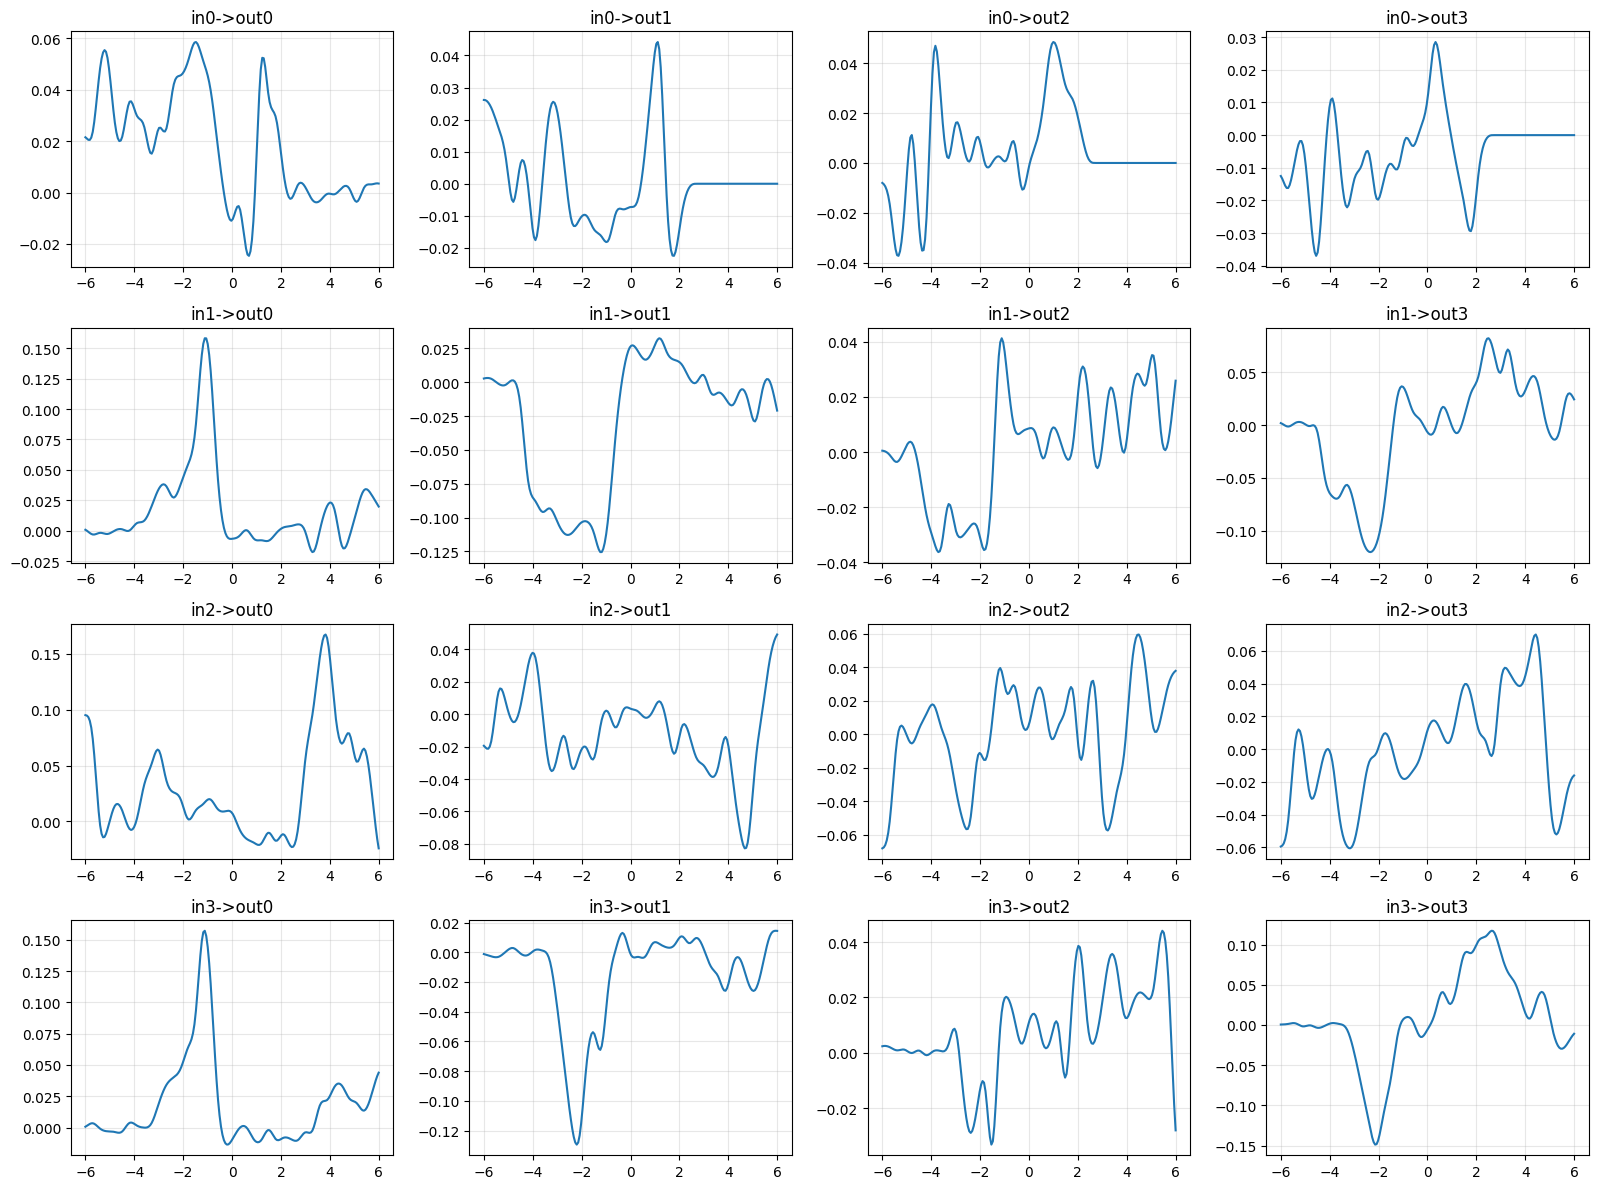

In [17]:
import sys
from pathlib import Path
import torch
import matplotlib.pyplot as plt

SEQKAN_ARTIGO = Path('/home/ferna/seqKAN_artigo')
if str(SEQKAN_ARTIGO) not in sys.path:
    sys.path.insert(0, str(SEQKAN_ARTIGO))

from seqkan.kan.spline import coef2curve

if 'model' not in globals():
    raise RuntimeError('Execute a célula de criação do model antes do plot.')

# Escolha a camada que quer visualizar
# Exemplo: encoder_ode_x -> seqkan -> kan_x -> primeira KANLayer
layer = model.encoder_ode_x.seqkan.kan_x.act_fun[0]

# Forçar CPU para evitar mismatch de device
layer = layer.cpu()

# Quantas curvas plotar (por entradas/saídas)
max_in = min(4, layer.in_dim)
max_out = min(4, layer.out_dim)

grid = layer.grid
k = layer.k

# Gera grade de plots
fig, axes = plt.subplots(max_in, max_out, figsize=(4 * max_out, 3 * max_in), squeeze=False)
for in_idx in range(max_in):
    x_min = grid[in_idx, k].item()
    x_max = grid[in_idx, -k-1].item()
    x = torch.linspace(x_min, x_max, 200)
    x_eval = torch.zeros(200, layer.in_dim)
    x_eval[:, in_idx] = x
    y_all = coef2curve(x_eval, grid, layer.coef, k).detach().cpu()
    for out_idx in range(max_out):
        ax = axes[in_idx][out_idx]
        y = y_all[:, in_idx, out_idx]
        ax.plot(x.numpy(), y.numpy())
        ax.set_title(f"in{in_idx}->out{out_idx}")
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()








In [18]:
import torch
from seqkan.kan.KANLayer import KANLayer
from seqkan.kan.spline import coef2curve

def extract_all_splines(model, n_points=200):
    """Extrai curvas (x,y) de todas as KANLayer do modelo."""
    splines = []
    with torch.no_grad():
        for name, module in model.named_modules():
            if not isinstance(module, KANLayer):
                continue
            grid = module.grid.detach().cpu()
            coef = module.coef.detach().cpu()
            k = int(module.k)
            in_dim = int(module.in_dim)
            out_dim = int(module.out_dim)

            x_eval = torch.zeros(n_points, in_dim)
            for in_idx in range(in_dim):
                x_min = grid[in_idx, k].item()
                x_max = grid[in_idx, -k - 1].item()
                x_eval[:, in_idx] = torch.linspace(x_min, x_max, n_points)

            y_eval = coef2curve(x_eval, grid, coef, k).detach().cpu()

            splines.append({
                'module': name,
                'in_dim': in_dim,
                'out_dim': out_dim,
                'k': k,
                'grid': grid,
                'coef': coef,
                'x_eval': x_eval,
                'y_eval': y_eval,
            })

    return splines

all_splines = extract_all_splines(model, n_points=200)
print(f'Extraidas {len(all_splines)} camadas KANLayer')

torch.save(all_splines, 'seqKAN_all_splines.pt')








Extraidas 6 camadas KANLayer


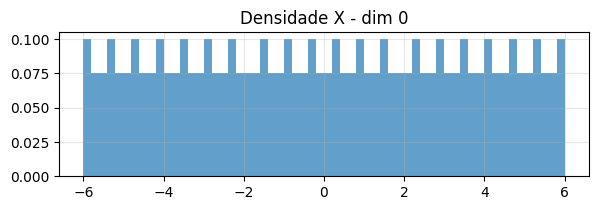

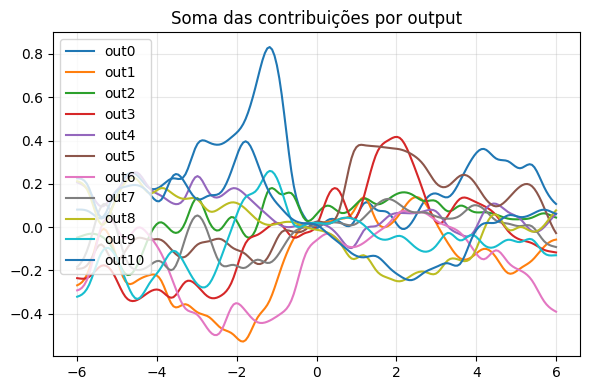

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# Assumindo que 'layer' e 'model' já existem e estão no CPU
# 1) Densidade dos dados no eixo X (por dimensão de entrada)
with torch.no_grad():
    try:
        x_data = x.detach().cpu()
    except Exception:
        x_data = torch.tensor(dl.df[list(dl.df.columns[:-3])].to_numpy(dtype=np.float32))

max_points = 5000
if x_data.numel() > 0 and x_data.shape[0] > max_points:
    idx = torch.randperm(x_data.shape[0])[:max_points]
    x_data = x_data[idx]

# garante 2D (N, C)
if x_data.ndim == 1:
    x_data = x_data.unsqueeze(1)

dims = list(range(x_data.shape[1]))
fig, axes = plt.subplots(len(dims), 1, figsize=(6, 2.2*len(dims)), squeeze=False)
for i, d in enumerate(dims):
    vals = x_data[:, d].numpy()
    vals = vals[~np.isnan(vals)]
    axes[i, 0].hist(vals, bins=60, density=True, alpha=0.7)
    axes[i, 0].set_title(f'Densidade X - dim {d}')
    axes[i, 0].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 2) Soma das contribuições por output
grid = layer.grid
k = layer.k
x_min = grid[0, k].item()
x_max = grid[0, -k-1].item()
x_axis = torch.linspace(x_min, x_max, 200)

x_eval = torch.zeros(200, layer.in_dim)
x_eval[:] = x_axis.unsqueeze(1)
y_all = coef2curve(x_eval, grid, layer.coef, k).detach().cpu()  # (N, in_dim, out_dim)
y_sum = y_all.sum(dim=1)  # (N, out_dim)

fig, ax = plt.subplots(1, 1, figsize=(6, 4))
for out_idx in range(y_sum.shape[1]):
    ax.plot(x_axis.numpy(), y_sum[:, out_idx].numpy(), label=f'out{out_idx}')
ax.set_title('Soma das contribuições por output')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()








In [20]:
# Carrega splines salvas e imprime a formula (coeficientes + grade)
import torch

splines = torch.load('/home/ferna/CPE727-2025-03/Seminarios/6 - RNN/seqKAN_all_splines.pt')
print(f'Camadas carregadas: {len(splines)}')

def print_spline_formula(s, in_idx=0, out_idx=0, max_terms=10):
    grid = s['grid']
    coef = s['coef']
    k = s['k']
    # coef shape: (in_dim, out_dim, G+k)
    c = coef[in_idx, out_idx].detach().cpu().numpy().tolist()
    print(f"Layer: {s['module']} | in={in_idx} -> out={out_idx} | k={k}")
    print("Formula: s(x) = sum_m c_m * B_m(x)  (B-splines de ordem k)")
    print("Grid:", grid[in_idx].detach().cpu().numpy().tolist())
    # mostra primeiros coeficientes para nao poluir
    preview = c[:max_terms]
    print("Coeficientes (primeiros):", preview)

# Exemplo: primeira camada, in0->out0
print_spline_formula(splines[0], in_idx=0, out_idx=0)








Camadas carregadas: 6
Layer: encoder_ode_x.seqkan.kan_x.act_fun.0 | in=0 -> out=0 | k=3
Formula: s(x) = sum_m c_m * B_m(x)  (B-splines de ordem k)
Grid: [-6.90000057220459, -6.600000381469727, -6.300000190734863, -6.0, -5.699999809265137, -5.400000095367432, -5.099999904632568, -4.800000190734863, -4.5, -4.199999809265137, -3.8999998569488525, -3.5999999046325684, -3.299999952316284, -3.0, -2.6999998092651367, -2.3999998569488525, -2.0999999046325684, -1.7999998331069946, -1.499999761581421, -1.1999998092651367, -0.8999997973442078, -0.5999997854232788, -0.29999977350234985, -2.384185791015625e-07, 0.29999977350234985, 0.5999997854232788, 0.8999997973442078, 1.1999998092651367, 1.499999761581421, 1.7999998331069946, 2.0999999046325684, 2.3999998569488525, 2.6999998092651367, 3.0, 3.299999952316284, 3.5999999046325684, 3.8999998569488525, 4.199999809265137, 4.5, 4.800000190734863, 5.099999904632568, 5.400000095367432, 5.699999809265137, 6.0, 6.300000190734863, 6.600000381469727, 6.90000

In [21]:
# Gera arquivo com todas as formulas das splines e totaliza quantidade
import torch

splines = torch.load('/home/ferna/CPE727-2025-03/Seminarios/6 - RNN/seqKAN_all_splines.pt')
total = 0
out_path = '/home/ferna/CPE727-2025-03/Seminarios/6 - RNN/seqKAN_all_splines_formulas.txt'

with open(out_path, 'w') as f:
    for s in splines:
        layer = s['module']
        in_dim = s['in_dim']
        out_dim = s['out_dim']
        k = s['k']
        grid = s['grid'].detach().cpu().numpy().tolist()
        coef = s['coef'].detach().cpu().numpy().tolist()
        f.write(f'Layer: {layer} | in_dim={in_dim} | out_dim={out_dim} | k={k}\n')
        for i in range(in_dim):
            for j in range(out_dim):
                total += 1
                f.write(f'  spline in{i}->out{j}: s(x) = sum_m c_m * B_m(x)\n')
                f.write(f'    grid: {grid[i]}\n')
                f.write(f'    coef: {coef[i][j]}\n')
        f.write('\n')

print(f'Total de splines: {total}')
print(f'Arquivo gerado: {out_path}')








Total de splines: 726
Arquivo gerado: /home/ferna/CPE727-2025-03/Seminarios/6 - RNN/seqKAN_all_splines_formulas.txt


In [22]:
# Gera as 43 funcoes base B_m(x) (piecewise) para todas as splines (todas as camadas)
# Requer sympy no ambiente do Jupyter
import torch
import sympy as sp
from sympy.functions.special.bsplines import bspline_basis_set

splines = torch.load('/home/ferna/CPE727-2025-03/Seminarios/6 - RNN/seqKAN_all_splines.pt')
out_path = '/home/ferna/CPE727-2025-03/Seminarios/6 - RNN/seqKAN_all_splines_basis_piecewise.txt'

x = sp.symbols('x', real=True)

with open(out_path, 'w') as f:
    for s in splines:
        layer = s['module']
        k = int(s['k'])
        grid = s['grid'].detach().cpu().numpy().tolist()
        f.write(f'Layer: {layer} | k={k}\n')
        for i in range(s['in_dim']):
            knots = tuple(sp.Float(v) for v in grid[i])
            f.write(f'  in{i}: knots={knots}\n')
            # numero de bases = len(knots) - k - 1
            n_basis = len(knots) - k - 1
            for m in range(n_basis):
                b = bspline_basis_set(k, knots, x)[m]
                f.write(f'    B_{m}(x) = {sp.simplify(b)}\n')
        f.write('\n')

print(f'Arquivo gerado: {out_path}')








KeyboardInterrupt: 